In [73]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd

testset_params = '../data/data/data/gas_tri_256/testpara.csv'
testparams = pd.read_csv(testset_params, index_col=0)
#load the data and parameters of the test set
testset_cmaps = np.load('cmaps_from_simulations_testset_parfile_R261_phi0.99_hd163296like3corr.npy')

In [6]:
emulations = h5py.File("cmaps_emulations_small.h5", "r", swmr=True)

In [15]:
testset_cmaps.shape

(233, 105, 250, 250)

In [16]:
testset = testset_cmaps[:, 42:64]

In [17]:
np.expand_dims?

Signature:       np.expand_dims(a, axis)
Call signature:  np.expand_dims(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function expand_dims at 0x7ff32c582d40>
File:            /exa/projects/DiscEvol_storage/alessandro.ruzza/emu+discminer/penv/lib/python3.10/site-packages/numpy/lib/_shape_base_impl.py
Docstring:      
Expand the shape of an array.

Insert a new axis that will appear at the `axis` position in the expanded
array shape.

Parameters
----------
a : array_like
    Input array.
axis : int or tuple of ints
    Position in the expanded axes where the new axis (or axes) is placed.

    .. deprecated:: 1.13.0
        Passing an axis where ``axis > a.ndim`` will be treated as
        ``axis == a.ndim``, and passing ``axis < -a.ndim - 1`` will
        be treated as ``axis == 0``. This behavior is deprecated.

Returns
-------
result : ndarray
    View of `a` with the number of dimensions increased.

See Also
--------
squeeze : The inverse operation, rem

In [19]:
bestest = {}
sigmas = {}
valmins = {}
errs = {}
rangelen = {'PlanetMass': 3, 'AspectRatio': 0.07, 'Alpha': 2}
params = ['PlanetMass', 'AspectRatio', 'Alpha']
mse = {}
for para in params:
    mse[para] = ((emulations[para]-np.expand_dims(testset, axis=1))**2).sum(axis=(-1,-2,-3))


<HDF5 file "cmaps_emulations_small.h5" (mode r)>

In [47]:
from tqdm import tqdm
grids = {'Alpha': np.logspace(-4,-2,20), 'PlanetMass': np.logspace(-5,-2,20), 'AspectRatio': np.linspace(0.03, 0.1,20)}
for para in tqdm(['PlanetMass', 'AspectRatio', 'Alpha']):
    sigmas_l = []
    sigmas_r = []
    for i in range(emulations[para].shape[0]):
        mses = mse[para][i]
        minimum = np.argmin(mses)
        N = np.min(mses)
        rm = minimum+1 if minimum<19 else 19
        lm = minimum-1 if minimum>0 else 0
        sigmas_l.append((1/((mses[lm]-2*mses[minimum]+mses[lm])/((rangelen[para])/100)**2/N))**0.5)
        sigmas_r.append((1/((mses[rm]-2*mses[minimum]+mses[rm])/((rangelen[para])/100)**2/N))**0.5)
    sigmas[para] = np.array([sigmas_l, sigmas_r])
    mins = np.argmin(mse[para], axis=1)
    bestest[para] = grids[para][mins]
    valmins[para] = np.min(mse[para], axis=1)
    if para=='AspectRatio':
        errs[para] = (-grids[para][mins]+sigmas[para][0]+grids[para][mins], grids[para][mins]+sigmas[para][1]-grids[para][mins])
    else:
        errs[para] = (-10**(np.log10(grids[para][mins])-sigmas[para][0])+grids[para][mins],
                      10**(np.log10(grids[para][mins])+sigmas[para][1])-grids[para][mins])

  0%|                                                                                                                                                                   | 0/3 [00:00<?, ?it/s]/scratch/ipykernel_3888560/4208787305.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  sigmas_l.append((1/((mses[lm]-2*mses[minimum]+mses[lm])/((rangelen[para])/100)**2/N))**0.5)
/scratch/ipykernel_3888560/4208787305.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  sigmas_r.append((1/((mses[rm]-2*mses[minimum]+mses[rm])/((rangelen[para])/100)**2/N))**0.5)
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 160.47it/s]


In [48]:
sigmas['PlanetMass'].shape

(2, 233)

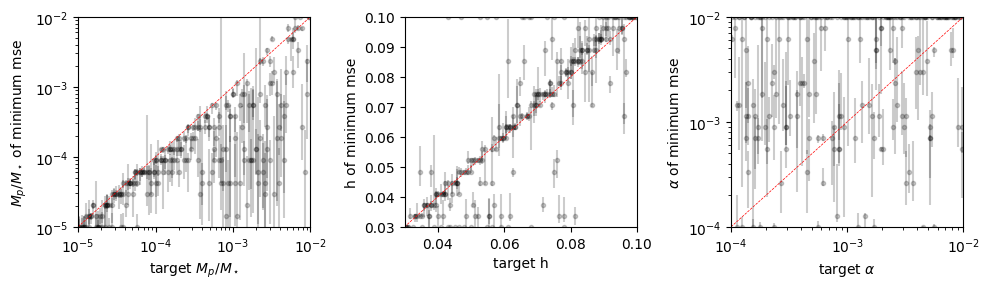

In [49]:
fig, axs = plt.subplots(1, 3, figsize=(10,3))
lims = {'Alpha': (1e-4, 1e-2), 'AspectRatio': (0.03, 0.1), 'PlanetMass': (1e-5,1e-2)}
labels = {'PlanetMass': '$M_p/M_\star$', 'AspectRatio': 'h', 'Alpha': '$\\alpha$'}
for i, para in enumerate(sigmas.keys()):
    axs[i].errorbar(testparams[para], 
                    bestest[para],
                    yerr=errs[para],
                    fmt='.',
                    color='black',
                    zorder=-1,
                   alpha=0.2)
    axs[i].set_rasterization_zorder(0)
    if i!=1:
        axs[i].set_xscale('log')
        axs[i].set_yscale('log')
    axs[i].set_xlim(*lims[para])
    axs[i].set_ylim(*lims[para])
    axs[i].plot(lims[para], lims[para], color='red', linewidth=0.5, linestyle='dashed')
    axs[i].set_xlabel(f'target {labels[para]}')
    axs[i].set_ylabel(f'{labels[para]} of minimum mse')

plt.tight_layout()
#plt.savefig('plots/varp_all.pdf', dpi=500, bbox_inches='tight')

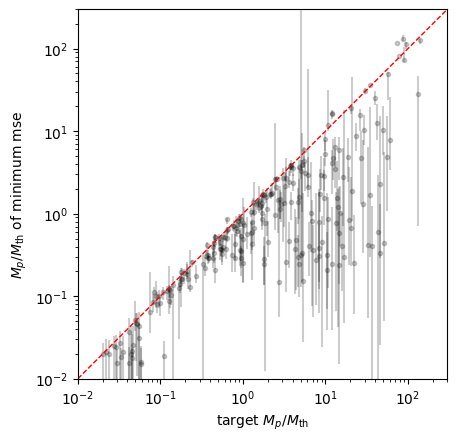

In [50]:
tmass_un = 3*testparams['PlanetMass']/(2*testparams['AspectRatio']**3)
para = 'PlanetMass'
plt.errorbar(3*testparams[para]/(2*testparams['AspectRatio']**3), 
                    3*bestest[para]/(2*testparams['AspectRatio']**3),
                    yerr=3*np.array(errs[para])/(2*np.array(testparams['AspectRatio']).reshape(1,-1)**3),
                    fmt='.',
                    color='black',
                    zorder=-1,
                   alpha=0.2)
plt.gca().set_rasterization_zorder(0)
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-2,300)
plt.ylim(1e-2, 300)
plt.plot(lims[para], lims[para], color='red', linewidth=0.5, linestyle='dashed')
plt.xlabel('target $M_p/M_\\text{th}$')
plt.ylabel('$M_p/M_\\text{th}$ of minimum mse')
plt.plot([1e-2,300], [1e-2,300], color='red', linestyle='dashed', linewidth=1)
plt.gca().set_aspect('equal')

In [57]:
sigmas['PlanetMass'].shape

(2, 233)

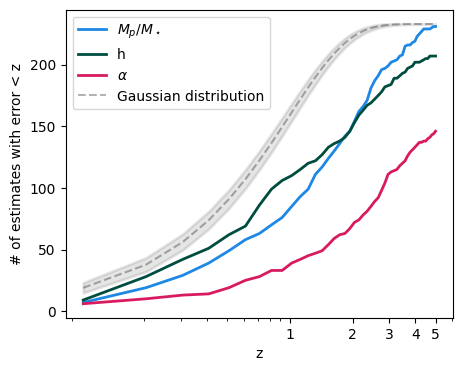

In [60]:
from scipy.stats import norm
colors = {'Alpha': '#D81B60', 'PlanetMass': '#1E88E5', 'AspectRatio': '#004D40'}

for para in sigmas.keys():
    nsigmas = sigmas[para][1]
    nsigmas[bestest[para]>testparams[para]] = sigmas[para][0][bestest[para]>testparams[para]]
    
    if para!='AspectRatio':
        errsigma = np.abs(np.log10(testparams[para])-np.log10(bestest[para]))/nsigmas
    else:
        errsigma = np.abs(testparams[para]-bestest[para])/nsigmas
    ecp, bins = np.histogram(errsigma, bins=np.linspace(0,5,50))
    ecp = np.cumsum(ecp)
    p = (norm.cdf(bins[1:])-0.5)*2
    plt.plot(bins[1:], ecp, linewidth=2, color=colors[para], label=labels[para])
    #plt.fill_between(bins[1:],  ecp-(len(errsigma)*p*(1-p))**0.5,  ecp+(len(errsigma)*p*(1-p))**0.5, linewidth=2, color=colors[para], alpha=0.3)

plt.xlabel('z')
plt.ylabel('# of estimates with error < z')
#plt.xlim(10,233)
#plt.ylim(10,233)
plt.plot(bins[1:], len(errsigma)*p, color='black', linestyle='dashed', alpha=0.3, label='Gaussian distribution')
plt.fill_between(bins[1:],  p*len(errsigma)-(len(errsigma)*p*(1-p))**0.5,   p*len(errsigma)+(len(errsigma)*p*(1-p))**0.5, linewidth=2, color='black', alpha=0.1)
#plt.gca().set_aspect('equal')
plt.legend()
plt.xscale('log')
plt.xticks(range(1,6), range(1,6))
plt.gcf().set_size_inches(5,4)
#plt.savefig('plots/zplot_simu.pdf', dpi=500, bbox_inches='tight')

# All with $\alpha=10^{-2}$ viscosity

In [62]:
emulations = h5py.File("cmaps_emulations_small_ALLalpha1e-2.h5", "r", swmr=True)

In [66]:
emulations['PlanetMass'].refresh()

In [70]:
bestest = {}
sigmas = {}
valmins = {}
errs = {}
rangelen = {'PlanetMass': 3, 'AspectRatio': 0.07, 'Alpha': 2}
params = ['PlanetMass', 'AspectRatio', 'Alpha']
mse = {}
for para in params:
    mse[para] = ((emulations[para]-np.expand_dims(testset, axis=1))**2).sum(axis=(-1,-2,-3))


In [71]:
from tqdm import tqdm
grids = {'Alpha': np.logspace(-4,-2,20), 'PlanetMass': np.logspace(-5,-2,20), 'AspectRatio': np.linspace(0.03, 0.1,20)}
for para in tqdm(['PlanetMass', 'AspectRatio', 'Alpha']):
    sigmas_l = []
    sigmas_r = []
    for i in range(emulations[para].shape[0]):
        mses = mse[para][i]
        minimum = np.argmin(mses)
        N = np.min(mses)
        rm = minimum+1 if minimum<19 else 19
        lm = minimum-1 if minimum>0 else 0
        sigmas_l.append((1/((mses[lm]-2*mses[minimum]+mses[lm])/((rangelen[para])/100)**2/N))**0.5)
        sigmas_r.append((1/((mses[rm]-2*mses[minimum]+mses[rm])/((rangelen[para])/100)**2/N))**0.5)
    sigmas[para] = np.array([sigmas_l, sigmas_r])
    mins = np.argmin(mse[para], axis=1)
    bestest[para] = grids[para][mins]
    valmins[para] = np.min(mse[para], axis=1)
    if para=='AspectRatio':
        errs[para] = (-grids[para][mins]+sigmas[para][0]+grids[para][mins], grids[para][mins]+sigmas[para][1]-grids[para][mins])
    else:
        errs[para] = (-10**(np.log10(grids[para][mins])-sigmas[para][0])+grids[para][mins],
                      10**(np.log10(grids[para][mins])+sigmas[para][1])-grids[para][mins])

  0%|                                                                                                                                                                   | 0/3 [00:00<?, ?it/s]/scratch/ipykernel_3888560/4208787305.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  sigmas_l.append((1/((mses[lm]-2*mses[minimum]+mses[lm])/((rangelen[para])/100)**2/N))**0.5)
/scratch/ipykernel_3888560/4208787305.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  sigmas_r.append((1/((mses[rm]-2*mses[minimum]+mses[rm])/((rangelen[para])/100)**2/N))**0.5)
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.49it/s]


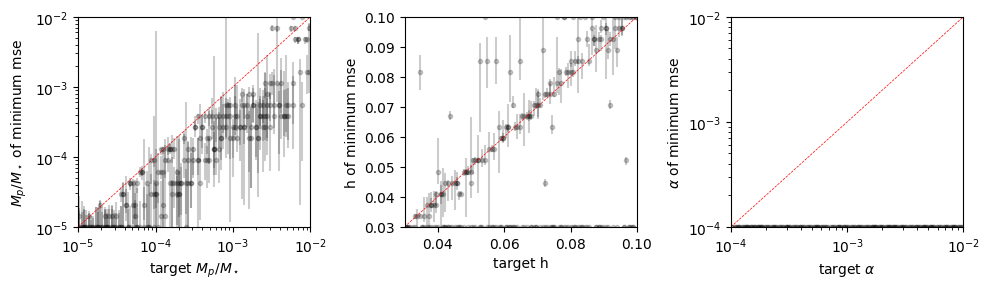

In [72]:
fig, axs = plt.subplots(1, 3, figsize=(10,3))
lims = {'Alpha': (1e-4, 1e-2), 'AspectRatio': (0.03, 0.1), 'PlanetMass': (1e-5,1e-2)}
labels = {'PlanetMass': '$M_p/M_\star$', 'AspectRatio': 'h', 'Alpha': '$\\alpha$'}
for i, para in enumerate(sigmas.keys()):
    axs[i].errorbar(testparams[para], 
                    bestest[para],
                    yerr=errs[para],
                    fmt='.',
                    color='black',
                    zorder=-1,
                   alpha=0.2)
    axs[i].set_rasterization_zorder(0)
    if i!=1:
        axs[i].set_xscale('log')
        axs[i].set_yscale('log')
    axs[i].set_xlim(*lims[para])
    axs[i].set_ylim(*lims[para])
    axs[i].plot(lims[para], lims[para], color='red', linewidth=0.5, linestyle='dashed')
    axs[i].set_xlabel(f'target {labels[para]}')
    axs[i].set_ylabel(f'{labels[para]} of minimum mse')

plt.tight_layout()
#plt.savefig('plots/varp_all.pdf', dpi=500, bbox_inches='tight')